# NLP Assignment: Language Modelling with Poetry (deadline **20.5.2026**)

This assignment will check your basic NLP understanding through the fundamental NLP task of **language modelling**.

You will reiterate on the task with techniques ranging from simple n-gram counting to embeddings and deep learning.


You will work with the same short poetry texts that should be very familiar to you by now:

In [1]:
!wget -nc https://raw.githubusercontent.com/GustikS/smu-nlp/master/robert_frost.txt
!wget -nc https://raw.githubusercontent.com/GustikS/smu-nlp/master/edgar_allan_poe.txt

--2026-05-13 12:54:31--  https://raw.githubusercontent.com/GustikS/smu-nlp/master/robert_frost.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56286 (55K) [text/plain]
Saving to: ‘robert_frost.txt’

robert_frost.txt    100%[===================>]  54.97K  --.-KB/s    in 0.01s   

2026-05-13 12:54:31 (4.76 MB/s) - ‘robert_frost.txt’ saved [56286/56286]

--2026-05-13 12:54:31--  https://raw.githubusercontent.com/GustikS/smu-nlp/master/edgar_allan_poe.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26622 (26K) [text/plain]
Sav

Unless stated otherwise (Ex. 4,5,6), work just with the Robert Frost file for simplicity (Ex. 1,2,3,7,8)

In [ ]:
!head robert_frost.txt

Two roads diverged in a yellow wood,
And sorry I could not travel both
And be one traveler, long I stood
And looked down one as far as I could
To where it bent in the undergrowth; 

Then took the other, as just as fair,
And having perhaps the better claim
Because it was grassy and wanted wear,
Though as for that the passing there


#### **Excercise 1**: Markov Language Model (**2 points**)

1. Create a 1st order Markov (bi-gram) language model
  - work with matrix representation of the model
    - i.e. not dictionaries as we did in the tutorial!
    - hence you'll need to assign indices to the words, too
      - include an extra \<UNK\> token for unseen words
  - correctly handle beginnings and ends of sentences
    - sentence = line (skip empty lines)
  - lower case and properly tokenize your sentences
    - but skip all other text preprocessing

In [2]:
# Standard library imports
import random

# Third-party imports
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# Create encoding of words (vocabulary)
# Initialize dictionary with special tokens:
# <UNK>: Unknown word token
# <s>: Start of sentence token
# </s>: End of sentence token
word2idx = {
    "<UNK>": 0,
    "<s>": 1,
    "</s>": 2,
}

# Counter for assigning new word indices
last_idx = 3

# Populate word2idx with words from the Robert Frost corpus
for line in open("robert_frost.txt"):
  # Tokenize each line, convert to lowercase, and remove trailing whitespace
  tokens = line.rstrip().lower().split()
  for token in tokens:
    # If word not in dictionary, add it with a new index
    if token not in word2idx:
      word2idx[token] = last_idx
      last_idx += 1

print(word2idx)

{'<UNK>': 0, '<s>': 1, '</s>': 2, 'two': 3, 'roads': 4, 'diverged': 5, 'in': 6, 'a': 7, 'yellow': 8, 'wood,': 9, 'and': 10, 'sorry': 11, 'i': 12, 'could': 13, 'not': 14, 'travel': 15, 'both': 16, 'be': 17, 'one': 18, 'traveler,': 19, 'long': 20, 'stood': 21, 'looked': 22, 'down': 23, 'as': 24, 'far': 25, 'to': 26, 'where': 27, 'it': 28, 'bent': 29, 'the': 30, 'undergrowth;': 31, 'then': 32, 'took': 33, 'other,': 34, 'just': 35, 'fair,': 36, 'having': 37, 'perhaps': 38, 'better': 39, 'claim': 40, 'because': 41, 'was': 42, 'grassy': 43, 'wanted': 44, 'wear,': 45, 'though': 46, 'for': 47, 'that': 48, 'passing': 49, 'there': 50, 'had': 51, 'worn': 52, 'them': 53, 'really': 54, 'about': 55, 'same,': 56, 'morning': 57, 'equally': 58, 'lay': 59, 'leaves': 60, 'no': 61, 'step': 62, 'trodden': 63, 'black.': 64, 'oh,': 65, 'kept': 66, 'first': 67, 'another': 68, 'day!': 69, 'yet': 70, 'knowing': 71, 'how': 72, 'way': 73, 'leads': 74, 'on': 75, 'doubted': 76, 'if': 77, 'should': 78, 'ever': 79, '

In [4]:
# Get the vocabulary size
V = len(word2idx)

# Initialize a V x V matrix with zeros to store bi-gram counts
model_matrix = np.zeros((V, V))

# Calculate the bi-gram counts from the Robert Frost corpus
for line in open("robert_frost.txt"):
  # Split sentence into tokens and convert to lowercase
  tokens = line.rstrip().lower().split()

  # Skip empty lines
  if not tokens:
    continue

  # Handle the transition from the start-of-sentence token to the first word
  first_idx = word2idx[tokens[0]]
  start_idx = word2idx["<s>"]
  model_matrix[start_idx][first_idx] += 1

  # Handle bi-gram transitions for words within the sentence
  for i in range(len(tokens)-1):
    current_idx = word2idx[tokens[i]]
    next_idx = word2idx[tokens[i+1]]
    model_matrix[current_idx][next_idx] += 1

  # Handle the transition from the last word to the end-of-sentence token
  last_idx = word2idx[tokens[-1]]
  end_idx = word2idx["</s>"]
  model_matrix[last_idx][end_idx] += 1

In [5]:
model_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [6]:
model_matrix[1][3]

np.float64(6.0)

#### **Excercise 2**: Probability + Smoothing (**2 points**)
1. write a function to obtain probability of a given sentence with your model
    - include the beginning and end mark of the sentence as well
    - test also some other sentences and assure the probability makes sense
      - write down your reasoning!
2. incorporate the add-1 (Laplace) smoothing to account for unseen bi-grams
    - you should have your \<UNK\> for unseen unigrams already
    - calculate prob. of "*the young folk held some hope out to each other.*"

In [7]:
# Helper function to get the index of a word, returning <UNK> index if unseen
def get_idx_of_word(word, word2idx):
  if word not in word2idx:
    return word2idx["<UNK>"]
  return word2idx[word]

# Function to calculate the probability of a given sentence using the bi-gram model
def get_sentence_probability(sentence, model_matrix, word2idx):
  # Tokenize the sentence and convert to lowercase
  tokens = sentence.lower().split()

  # Initialize probability with the transition from <s> to the first word
  # Use get_idx_of_word to handle potential <UNK> tokens
  first_idx = get_idx_of_word(tokens[0], word2idx)
  start_idx = word2idx["<s>"]
  prob = model_matrix[start_idx][first_idx]

  # Multiply probabilities for all subsequent bi-grams in the sentence
  for i in range(len(tokens)-1):
    current_idx = get_idx_of_word(tokens[i], word2idx)
    next_idx = get_idx_of_word(tokens[i+1], word2idx)
    prob *= model_matrix[current_idx][next_idx]

  # Multiply by the probability of the last word transitioning to </s>
  last_idx = get_idx_of_word(tokens[-1], word2idx)
  end_idx = word2idx["</s>"]
  prob *= model_matrix[last_idx][end_idx]

  return prob

In [8]:
# Calculate row sums for normalization: sum of counts for each word
row_sums = model_matrix.sum(axis=1, keepdims=True)
print(row_sums)

# Initialize a new matrix for normalized probabilities
model_normalized = np.zeros_like(model_matrix)

# Normalize the model_matrix by dividing each row by its sum
# This converts counts into probabilities (P(next_word | current_word))
for i in range(V):
  if row_sums[i] > 0:
    model_normalized[i] = model_matrix[i] / row_sums[i]

model_normalized

[[0.000e+00]
 [1.436e+03]
 [0.000e+00]
 ...
 [1.000e+00]
 [1.000e+00]
 [1.000e+00]]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [9]:
model_normalized[1][3]

np.float64(0.004178272980501393)

In [10]:
# Define a list of test sentences, including one with known words and one with unknown words
test_sentences = [
    "Two roads diverged in a yellow wood,",
    "I walked out in rain",
    "The woods are lovely, dark and deep,",
    "the young folk held some hope out to each other.",
    "A completely made up sentence with unknown words."
]

print("Testing get_sentence_probability function:")
# Iterate through each test sentence and print its calculated probability
for sentence in test_sentences:
    prob = get_sentence_probability(sentence, model_normalized, word2idx)
    print(f"Probability of '{sentence}': {prob}")


Testing get_sentence_probability function:
Probability of 'Two roads diverged in a yellow wood,': 5.486177758011282e-08
Probability of 'I walked out in rain': 5.107939471411927e-08
Probability of 'The woods are lovely, dark and deep,': 2.4009855982191383e-09
Probability of 'the young folk held some hope out to each other.': 2.2937809531998675e-12
Probability of 'A completely made up sentence with unknown words.': 0.0


### Reasoning for Sentence Probabilities
* The calculated probabilities are low (e.g., $10^{-8}$ to $10^{-12}$). This is expected because we are multiplying multiple probabilities, each of which is a small fraction between $0$ and $1$. Furhermore, shorter sentences like `"I walked out in rain."` tent to have higher probability ($10^{-8}$) than longer sentence `"the young folk held some hope out to each other"` $10^{-12}$.

* The sentence "A completely made up sentence with unknown words." has a 0.0 probability because it contains word pairs that the model never saw during training. In our math, these unseen pairs are treated as a zero. Since we are multiplying all the word probabilities together, a single zero make the whole result equals zero. This is the main problem with a model that doesn't use smoothing. If we used smoothing, this would be fixed because the model would give small probability to every possible word pair, even if it never saw them before. This ensures that no sentence ever gets a hard zero score.


In [11]:
# Implementing Laplace smoothing by adding 1 to all counts in the model matrix
model_smoothed = model_matrix + 1

# Recalculate row sums for the smoothed matrix
row_sums_smoothed = model_smoothed.sum(axis=1, keepdims=True)

# Normalize the smoothed matrix to get smoothed probabilities
model_smoothed_normalized = model_smoothed / row_sums_smoothed
model_smoothed_normalized

array([[0.00032712, 0.00032712, 0.00032712, ..., 0.00032712, 0.00032712,
        0.00032712],
       [0.00022257, 0.00022257, 0.00022257, ..., 0.00022257, 0.00022257,
        0.00022257],
       [0.00032712, 0.00032712, 0.00032712, ..., 0.00032712, 0.00032712,
        0.00032712],
       ...,
       [0.00032701, 0.00032701, 0.00065402, ..., 0.00032701, 0.00032701,
        0.00032701],
       [0.00032701, 0.00032701, 0.00032701, ..., 0.00032701, 0.00032701,
        0.00032701],
       [0.00032701, 0.00032701, 0.00065402, ..., 0.00032701, 0.00032701,
        0.00032701]])

In [12]:
# Define the test sentence for smoothed probability calculation
test_sentence = "the young folk held some hope out to each other."
# Calculate and print the probability using the smoothed model
prob = get_sentence_probability(test_sentence, model_smoothed_normalized, word2idx)
prob

np.float64(1.381204445709752e-33)

#### **Excercise 3**: Perplexity (**1 points**)
1. write a function fo calculate perplexity of your smoothed model on a given sentence
  - including its beginning and ending
2. find the sentence(s) from the corpus with minimum and maximum perplexity

In [13]:
# Function to calculate perplexity of a sentence using the smoothed model
def calculate_perplexity_of_sentence(sentence, model_matrix, word2idx):
  # Get the probability of the sentence using the smoothed, normalized model
  prob = get_sentence_probability(sentence, model_smoothed_normalized, word2idx)
  # Calculate the number of tokens (words + start/end tokens)
  num_of_tokens = len(sentence.split()) + 2
  # Compute perplexity: (P(sentence)) ^ -(1 / N), where N is number of tokens
  perplexity = prob ** (-1/num_of_tokens)
  return perplexity

In [14]:
perplexity = calculate_perplexity_of_sentence(test_sentence, model_smoothed_normalized, word2idx)
perplexity

np.float64(547.4088772699212)

In [15]:
# Initialize variables to track minimum and maximum perplexity and their corresponding sentences
min_perplexity = float('inf')
max_perplexity = float('-inf')
sentence_min_perplexity = ""
sentence_max_perplexity = ""

# Open the Robert Frost corpus to find sentences with min/max perplexity
for line in open("robert_frost.txt"):
  sentence = line.strip()
  if not sentence:
    continue

  # Calculate perplexity for the current sentence
  current_perplexity = calculate_perplexity_of_sentence(sentence, model_smoothed_normalized, word2idx)

  # Update min perplexity if current sentence has a lower perplexity
  if current_perplexity < min_perplexity:
    min_perplexity = current_perplexity
    sentence_min_perplexity = sentence

  # Update max perplexity if current sentence has a higher perplexity
  if current_perplexity > max_perplexity:
    max_perplexity = current_perplexity
    sentence_max_perplexity = sentence

print(f"Sentence with minimum perplexity: {sentence_min_perplexity}")
print(f"Perplexity: {min_perplexity}")
print(f"\nSentence with maximum perplexity: {sentence_max_perplexity}")
print(f"Perplexity: {max_perplexity}")

Sentence with minimum perplexity: it.
Perplexity: 75.58882430706944

Sentence with maximum perplexity: Life long in bed, and wrote her things in bed.
Perplexity: 843.0832140784601


#### **Excercise 4:**  Markov classifier (**4 points**)
Implement your own probabilistic classifier based on your bi-gram language model. That is:
  1. given some classes of sentences, train a separate language model for each class respectively
  2. then classify a given sentence (=sample) based on maximum a-posteriori probability (MAP)
    - i.e. don't forget about the class priors, too!
    - use log probabilities!
    - make sure your smoothing treats all the classes equally!
      - ...think about what happens to the UNK token
  3. evaluate on a task of recognizing sentences from the 2 different poets (Frost vs. Poe)
    - split the sentences (=samples) from each poet into train-test in advance!
      - fixed train-test split 70:30
        - do not shuffle sentences
      - skip empty lines (of course)
 	- report all accuracy values + a confusion matrix

*Note that this is very similar to our previous classification with Naive Bayes, but with bi-grams instead of unigrams.*

In [16]:
# Function to extend the word2idx mapping with words from a given file
def create_mapping_of_words(word2idx, last_idx, filename):
  for line in open(filename):
    # Tokenize the line, convert to lowercase, and remove trailing whitespace
    tokens = line.rstrip().lower().split()
    for token in tokens:
      # If a token is not already in the word2idx dictionary, add it
      if token not in word2idx:
        word2idx[token] = last_idx
        last_idx += 1
  return last_idx # Return the updated last_idx

In [17]:
# Initialize word2idx with special tokens and starting index for new words
word2idx = {
    "<UNK>": 0,
    "<s>": 1,
    "</s>": 2,
}

last_idx = 3

# Create mapping for Robert Frost's text
last_idx = create_mapping_of_words(word2idx, last_idx, "robert_frost.txt")
print("Number of words in mapping after robert frost: ", len(word2idx))

# Create mapping for Edgar Allan Poe's text (extending the existing dictionary)
last_idx = create_mapping_of_words(word2idx, last_idx, "edgar_allan_poe.txt")
print("Number of words in mapping after edgar allan poe: ", len(word2idx))

Number of words in mapping after robert frost:  3057
Number of words in mapping after edgar allan poe:  4229


In [18]:
# Function to load all non-empty lines from a text file
def load_text(filename):
  all_lines = []
  for line in open(filename):
    l = line.rstrip().lower()
    if l:
      all_lines.append(l)
  return all_lines

In [19]:
# Function to split sentences from a file into training and testing sets
def train_test_split(filename):
  # Load all lines from the specified file
  all_lines = load_text(filename)

  # Determine the split index for 70% training data
  split_idx = int(len(all_lines) * 0.7)

  # Split the lines into training and testing sets
  train_lines = all_lines[:split_idx]
  test_lines = all_lines[split_idx:]

  return train_lines, test_lines

In [20]:
# Perform train-test split for Robert Frost's poems
train_frost, test_frost = train_test_split("robert_frost.txt")
# Perform train-test split for Edgar Allan Poe's poems
train_poe, test_poe = train_test_split("edgar_allan_poe.txt")

In [21]:
print(f"Number of train lines: {len(train_frost)}, number of test lines: {len(test_frost)}")

Number of train lines: 1005, number of test lines: 431


In [22]:
print(f"Number of train lines: {len(train_poe)}, number of test lines: {len(test_poe)}")

Number of train lines: 502, number of test lines: 216


In [23]:
# Function to train a bi-gram language model with add-1 smoothing
def train_model(train_set, word2idx):
  # Get the vocabulary size
  V = len(word2idx)
  # Initialize a V x V matrix for bi-gram counts
  model_matrix = np.zeros((V, V))

  # Compute counts of bi-grams from the training set
  for line in train_set:
    tokens = line.split()

    if not tokens:
      continue

    # Handle transition from start-of-sentence token to the first word
    first_idx = get_idx_of_word(tokens[0], word2idx)
    start_idx = word2idx["<s>"]
    model_matrix[start_idx][first_idx] += 1

    # Handle transitions for words within the sentence
    for i in range(len(tokens)-1):
      current_idx = get_idx_of_word(tokens[i], word2idx)
      next_idx = get_idx_of_word(tokens[i+1], word2idx)
      model_matrix[current_idx][next_idx] += 1

    # Handle transition from the last word to the end-of-sentence token
    last_idx = get_idx_of_word(tokens[-1], word2idx)
    end_idx = word2idx["</s>"]
    model_matrix[last_idx][end_idx] += 1

  # Apply add-1 (Laplace) smoothing and normalize the matrix
  model_smoothed = model_matrix + 1
  row_sums_smoothed = model_smoothed.sum(axis=1, keepdims=True)
  model_smoothed_normalized = model_smoothed / row_sums_smoothed

  return model_smoothed_normalized

In [24]:
# Train separate bi-gram models for Robert Frost and Edgar Allan Poe
frost_model = train_model(train_frost, word2idx)
poe_model = train_model(train_poe, word2idx)

# Calculate class priors (probability of a sentence belonging to a poet)
total_lines = len(train_frost) + len(train_poe)
prior_frost = len(train_frost) / total_lines
prior_poe = len(train_poe) / total_lines

# Convert priors to log probabilities for use with log-likelihoods
log_prior_frost = np.log(prior_frost)
log_prior_poe = np.log(prior_poe)

In [25]:
# Function to calculate the log probability of a sentence using a bi-gram model
def get_sentence_log_probability(sentence, model_matrix, word2idx):
    tokens = sentence.lower().split()

    # Get the log probability of the transition from <s> to the first word
    first_idx = get_idx_of_word(tokens[0], word2idx)
    start_idx = word2idx["<s>"]
    prob = np.log(model_matrix[start_idx][first_idx])

    # Add the log probabilities of subsequent bi-gram transitions
    for i in range(len(tokens)-1):
        current_idx = get_idx_of_word(tokens[i], word2idx)
        next_idx = get_idx_of_word(tokens[i+1], word2idx)
        prob += np.log(model_matrix[current_idx][next_idx])

    # Add the log probability of the transition from the last word to </s>
    last_idx = get_idx_of_word(tokens[-1], word2idx)
    end_idx = word2idx["</s>"]
    prob += np.log(model_matrix[last_idx][end_idx])

    return prob

In [26]:
# Function to classify a sentence based on bi-gram language models and class priors
def classify_sentence(sentence, models, priors, word2idx):
  # Calculate the log posterior probability for Robert Frost's class
  score_frost = get_sentence_log_probability(sentence, models[0], word2idx) + priors[0]
  # Calculate the log posterior probability for Edgar Allan Poe's class
  score_poe = get_sentence_log_probability(sentence, models[1], word2idx) + priors[1]

  if score_frost > score_poe:
    # Return 0 for Frost
    return 0
  else:
    # Return 1 for Poe
    return 1

In [27]:
# Initialize lists to store true labels and predicted labels
# 0 = Robert Frost, 1 = Edgar Allan Poe
y_true = []
y_pred = []

# Test the classifier on Robert Frost's test sentences
for line in test_frost:
  y_true.append(0)
  res = classify_sentence(line, [frost_model, poe_model], [log_prior_frost, log_prior_poe], word2idx)
  y_pred.append(res)

# Test the classifier on Edgar Allan Poe's test sentences
for line in test_poe:
  y_true.append(1)
  res = classify_sentence(line, [frost_model, poe_model], [log_prior_frost, log_prior_poe], word2idx)
  y_pred.append(res)

In [28]:
# Printing accuracy
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

Accuracy: 0.8470


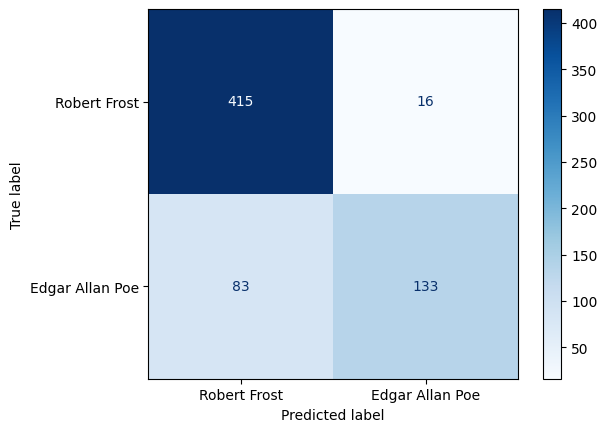

In [30]:
# Visualize the confusion matrix to show classification performance
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Robert Frost", "Edgar Allan Poe"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

#### **Excercise 5**: PPMI word-word cooccurence (**1 points**)
1. Create a word-word co-occurence matrix from all the text of both the poets altogether
  - use a sliding window of size 5 (2 left + 2 right context words)
    - remember that you can reuse existing solutions...
2. Post-process the matrix with PPMI

In [31]:
# Get all text from both poets combined
all_text_frost = load_text("robert_frost.txt")
all_text_poe = load_text("edgar_allan_poe.txt")

all_text = all_text_frost + all_text_poe

# Compute co-occurrence matrix using a sliding window
co_oc_matrix = np.zeros((len(word2idx), len(word2idx)))

for line in all_text:
  tokens = line.split()
  # For each token, consider its context words
  for i, token in enumerate(tokens):
    target_idx = word2idx[token]
    # Define the sliding window: 2 words to the left, 2 words to the right
    start = max(0, i-2)
    end = min(len(tokens), i+3)
    for j in range(start, end):
      if i != j:
        context_idx = word2idx[tokens[j]]
        co_oc_matrix[target_idx][context_idx] += 1
co_oc_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.]])

In [32]:
# Function to compute PPMI matrix
def compute_ppmi(co_oc_matrix):
  # Compute marginal probabilities
  col_totals = co_oc_matrix.sum(axis=0)
  row_totals = co_oc_matrix.sum(axis=1)
  total = col_totals.sum()
  # Compute expected co-occurrence counts under assumption of independence
  expected = np.outer(row_totals, col_totals) / total
  # Add a small epsilon (1e-9) to avoid division by zero and log(0)
  ppmi_matrix = np.log((co_oc_matrix / (expected + 1e-9)) + 1e-9)

  # Replace negative PPMI values with 0
  ppmi_matrix = np.maximum(0, ppmi_matrix)
  return ppmi_matrix

In [33]:
# Compute the PPMI matrix from the co-occurrence matrix
ppmi_matrix = compute_ppmi(co_oc_matrix)

#### **Excercise 6**: Word embeddings (**1 points**)
1. Extract 8-dimensional word embeddings from your PPMI matrix
  - using the truncated SVD matrix decomposition
2. Plot them in 2D with word labels

In [34]:
# 1. Extract 8-dimensional word embeddings from the PPMI matrix using Truncated SVD
svd = TruncatedSVD(n_components=8, random_state=42)
embeddings_8d = svd.fit_transform(ppmi_matrix)
print("8d embeddings: ")
print(embeddings_8d)

# 2. Reduce the 8-dimensional word embeddings to 2-dimensions for visualization using t-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_8d)
print("2d embeddings: ")
print(embeddings_2d)

8d embeddings: 
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.43938852  0.4703367   0.21038138 ...  1.0548106  -0.45762761
   0.28731165]
 [ 0.65222294  0.50387159  0.1324225  ...  0.92543455 -0.46211992
   0.52240673]
 [ 0.44549058 -0.0223281  -0.03830222 ...  0.29106089 -0.09002273
   0.42196365]]
2d embeddings: 
[[  9.524409  -69.15992  ]
 [  9.321792  -67.85166  ]
 [  9.01173   -68.64594  ]
 ...
 [ 46.109337   30.710981 ]
 [ 40.938545   30.784283 ]
 [  3.2127233 -45.05375  ]]


In [35]:
# Get some random testing words

# Get all words from dictionary keys
all_words = list(word2idx.keys())

# Remove special tokens if you don't want them in your plot
tokens_to_ignore = {"<s>", "</s>", "<UNK>"}
filtered_words = [w for w in all_words if w not in tokens_to_ignore]

# Randomly select unique words for plotting
test_words = random.sample(filtered_words, 20)
print(test_words)

['woodland', 'imagine', 'band-music', 'ranged,', '(and', 'growing', 'seen.', "'how", 'pale', 'mine.', 'gazing,', 'your', 'snow!', 'fine', 'fingers,', 'thought', 'battle', 'shame', 'ahead', 'good,']


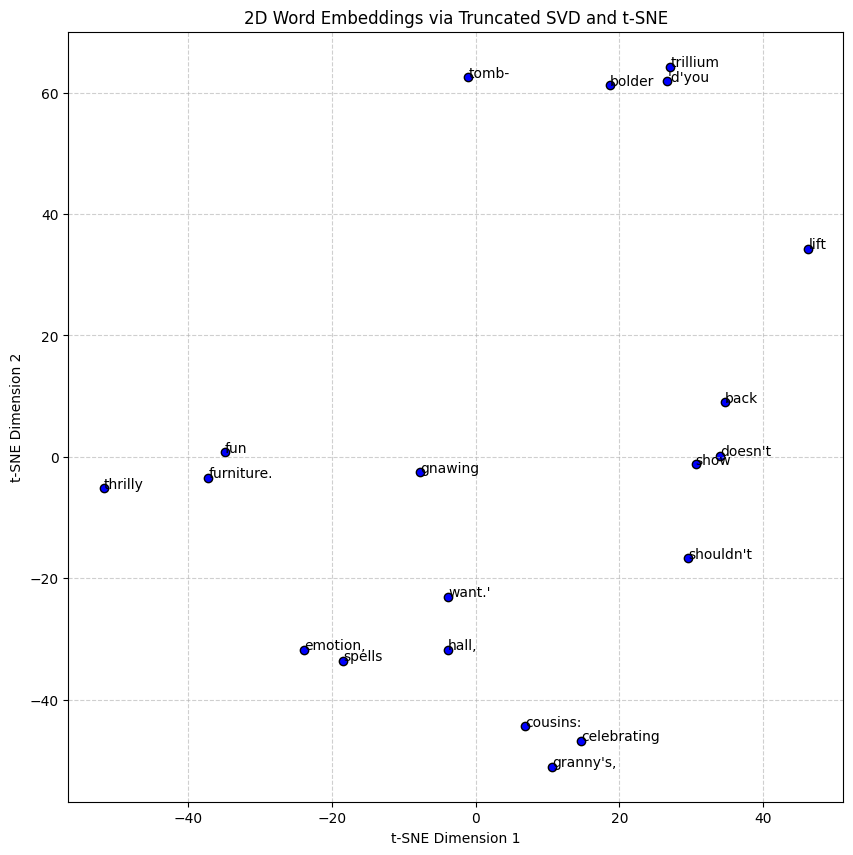

In [36]:
# 3. Plotting 2d embeddings of selected words
# test_words = ['hide.', 'object-', 'duty-', 'towns', "are.'", 'town', 'swift.', 'dale', 'origin', 'look-', 'liquescent', 'narrow', 'month', 'figures', 'hamadryad', 'taken', 'get.', 'lurid', 'ascending', 'crust']
test_words = ['hall,', "granny's,", 'celebrating', 'cousins:', 'trillium', 'emotion,', 'show', "doesn't", 'tomb-', 'thrilly', 'back', 'gnawing', 'lift', "shouldn't", "'d'you", 'furniture.', 'fun', 'bolder', "want.'", 'spells']

plt.figure(figsize=(10,10)) # Increased figure size for better readability

# Plot each selected word's 2D embedding
for word in test_words:
  word_idx = word2idx[word]
  x, y = embeddings_2d[word_idx]
  plt.scatter(x, y, edgecolors='k', c='b')
  plt.text(x+0.03, y+0.03, word)
plt.title('2D Word Embeddings via Truncated SVD and t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid
plt.show()

#### **Excercise 7:** LSTM Language Model (**3 points**)
1. Formulate a proper dataset for language modelling on longer sequences from the text
  - beyond the n-gram scope, use 10 consecutive words
2. Create a suitable LSTM-based language model
3. Initialize the embedding layer of your model with your "pretrained" SVD embeddings
4. Train the model in a suitable fashion

In [37]:
# Function to load all lines from both poets, tokenize, add special tokens, and map to IDs
def load_all_lines():
  all_lines_frost = load_text("robert_frost.txt")
  all_lines_poe = load_text("edgar_allan_poe.txt")
  all_lines = all_lines_frost + all_lines_poe

  all_lines_flat = []
  for line in all_lines:
    tokens = line.split()
    if not tokens: continue
    # Add start and end-of-sentence tokens to each line for context
    tokens = ["<s>"] + tokens + ["</s>"]
    # Map words to their numerical indices
    tokens_mapped = [get_idx_of_word(token, word2idx) for token in tokens]
    # Extend the flattened list with mapped tokens from the current line
    all_lines_flat.extend(tokens_mapped)

  return all_lines_flat

# Function to create a dataset for language modeling (sequences of 10 words, predict the 11th)
def create_dataset():
  all_lines_flat = load_all_lines()

  X = []
  y = []
  window_size = 10

  # Iterate through the flattened sequence to create (input, target) pairs
  for i in range(len(all_lines_flat) - window_size):
      # The input sequence (X) is 10 consecutive words
      sequence = all_lines_flat[i : i + window_size]
      # The target (y) is the 11th word following the sequence
      target = all_lines_flat[i + window_size]
      X.append(sequence)
      y.append(target)

  # Convert lists to NumPy arrays for efficient processing
  X = np.array(X)
  y = np.array(y)

  return X, y

In [38]:
X, y = create_dataset()

In [39]:
X[0]

array([1, 3, 4, 5, 6, 7, 8, 9, 2, 1])

In [40]:
class PoetLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pretrained_embeddings):
        super(PoetLSTM, self).__init__()
        # Embedding Layer - initialized with pre-trained SVD embeddings
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # Copy the computed 8D embeddings into the embedding layer's weights
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
        # Allow the embedding layer weights to be fine-tuned during training
        self.embedding.weight.requires_grad = True

        # The LSTM Layer: processes sequences of embedded words
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True) # batch_first means input/output tensors have batch dimension first

        # Dropout layer to prevent overfitting
        self.dropout = nn.Dropout(0.2)

        # The Output Layer (Linear): maps LSTM's hidden state to vocabulary size
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
      # Pass input (word indices) through the embedding layer
      embedded = self.embedding(x)
      # Pass embeddings through the LSTM layer
      out, (h_n, c_n) = self.lstm(embedded)
      # Get the hidden state of the last word in the sequence (relevant for prediction)
      last_output = out[:, -1, :]
      # Apply dropout for regularization
      out = self.dropout(last_output)
      # Map the final hidden state to logit scores for each word in the vocabulary
      logits = self.fc(out)
      return logits

In [41]:
# Convert NumPy arrays (X, y) to PyTorch LongTensors
X_train_tensor = torch.LongTensor(X)
y_train_tensor = torch.LongTensor(y)

# Group X and y together into a TensorDataset object
dataset = TensorDataset(X_train_tensor, y_train_tensor)

#  Create a DataLoader for efficient batching and shuffling during training
train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

In [42]:
# Hyperparameters for the LSTM model
VOCAB_SIZE = len(word2idx)
EMBED_DIM = 8
HIDDEN_DIM = 128
LEARNING_RATE = 0.001

# Instantiate the PoetLSTM model
model = PoetLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, embeddings_8d)

# Define the loss function
criterion = nn.CrossEntropyLoss()
# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for batch_idx, (sequences, targets) in enumerate(train_loader):
        # 1. Move data (input sequences and target words) to the same device as the model
        sequences = sequences.to(device)
        targets = targets.to(device)

        # 2. Clear previous gradients before a new backward pass
        optimizer.zero_grad()

        # 3. Forward pass: compute model outputs
        outputs = model(sequences)

        # 4. Calculate the loss between model outputs and true targets
        loss = criterion(outputs, targets)

        # 5. Backward pass: compute gradients of the loss with respect to model parameters
        loss.backward()

        # 6. Optimize: update model weights based on computed gradients
        optimizer.step()

        running_loss += loss.item()

    # Calculate and print average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/20], Loss: 6.2116
Epoch [2/20], Loss: 5.4565
Epoch [3/20], Loss: 5.1491
Epoch [4/20], Loss: 4.9348
Epoch [5/20], Loss: 4.7397
Epoch [6/20], Loss: 4.5507
Epoch [7/20], Loss: 4.3717
Epoch [8/20], Loss: 4.2011
Epoch [9/20], Loss: 4.0236
Epoch [10/20], Loss: 3.8630
Epoch [11/20], Loss: 3.6912
Epoch [12/20], Loss: 3.5313
Epoch [13/20], Loss: 3.3832
Epoch [14/20], Loss: 3.2285
Epoch [15/20], Loss: 3.0844
Epoch [16/20], Loss: 2.9514
Epoch [17/20], Loss: 2.8108
Epoch [18/20], Loss: 2.6809
Epoch [19/20], Loss: 2.5607
Epoch [20/20], Loss: 2.4462


 #### **Excercise 8**: Sampling (**1 point**)
1. Sample some text from your models w.r.t. to the output (next) word probability distribution
  - for both bigram and LSTM models - which is better?

2. Paste your best "poem" here:

In [43]:
# Create a dictionary to map numerical indices back to words
idx2word = {idx: word for word, idx in word2idx.items()}

In [44]:
# Function to generate text using the trained LSTM model
def generate_lstm_text(model, start_str, word2idx, idx2word, length=20, temperature=1.0):
    model.eval()
    words = start_str.lower().split()

    for _ in range(length):
        # 1. Prepare the input sequence: take the last 10 words as context
        input_seq = [get_idx_of_word(w, word2idx) for w in words[-10:]]
        # Pad with <UNK> tokens if the starting string is shorter than 10 words
        while len(input_seq) < 10:
            input_seq.insert(0, word2idx['<UNK>'])

        # Convert the input sequence to a PyTorch tensor and move to device
        input_tensor = torch.LongTensor([input_seq]).to(device)

        # 2. Get the raw predictions
        with torch.no_grad():
            logits = model(input_tensor)

        # 3. Convert logits to probabilities using softmax and apply temperature
        probs = torch.softmax(logits / temperature, dim=-1).cpu().numpy()[0]

        # 4. Sample a word index based on the calculated probabilities
        next_idx = np.random.choice(len(probs), p=probs)

        # 5. Append the sampled word to the generated text
        words.append(idx2word[next_idx])

    return " ".join(words)

In [45]:
# Define a starting string for text generation
seed_text = "The woods are lovely"

# Generate a poem using the LSTM model
generated_poem = generate_lstm_text(
    model=model,
    start_str=seed_text,
    word2idx=word2idx,
    idx2word=idx2word,
    length=50,
    temperature=0.8
)

print("LSTM Gerenated Poem")
print(generated_poem)

LSTM Gerenated Poem
the woods are lovely </s> <s> come that who they done! i must voices it. </s> <s> that if he someone - it, will was something- </s> <s> here in an open be in thine - so's - </s> <s> the melancholy bones are it starks </s> <s> but only a family home: </s>


In [46]:
# Train a bigram model on the combined dataset
combined_bigram_model = train_model(all_text, word2idx)

In [47]:
# Function to generate text using the bigram model
def generate_bigram_text(model_matrix, word2idx, idx2word, start_token="<s>", max_length=50):
    current_idx = word2idx[start_token]
    sentence = []

    for _ in range(max_length):
        # Get the row of probabilities for the current word
        probs = model_matrix[current_idx]

        # Sample the next word index based on those probabilities
        next_idx = np.random.choice(len(probs), p=probs)

        if next_idx not in idx2word:
          continue

        sentence.append(idx2word[next_idx])
        current_idx = next_idx

    return " ".join(sentence)

# Generate a sentence using the bigram model and print it
result_sentence = generate_bigram_text(combined_bigram_model, word2idx, idx2word)
print(result_sentence)

wanted rug fervid, 'do folk do, or 'tis 'twas relationship, profanation, is couldn't blade thought, meeting dent perfect furs theirs ramparts breathe.' husband back. achilles wake repeatedly held alone. eyes- two. cock- slave. man, point where's there,' trade and throng mouth- detail- sill- brushed distinctly,- seen 'who'd utterance less resembles


### Comparison of Bigram vs. LSTM Generated Text


*   **Bigram Model**:
* Output text of bigram mode: `"weeks stifling fresh groan pure smoking full-orbed won't, fly! folk. door, protection.' sea defied fast strong town. pretty pole— hyacinthine weir.' crew head. ceasing wild, intense owe forgot, nebulous rear'd oh bade strain's"`
* Bigram model quickly turns into a random list of words that doesn't follow grammar or stay on topic. Because it can only look at two words at a time, it fails to understand how to build long sentences or keep a consistent idea going.

*   **LSTM Model**:
* Output text of LSTM model: `"the woods are lovely </s> <s> night-time heaven. domes ways, heaven. around, october, </s> <s> good, scultur'd lyre ungodly throne luminous scultur'd jewelled </s> <s> shudder pendulous shudder blend time. creases! tremble stand </s> <s> beaming best, finger, melancholy undivided melancholy morning- not! sweet good, ruby </s> <s> mountains- gloom! remembered champions thou: </s>"`.
* Compared to the simpler bigram model, its poems stay on topic longer and follow better grammar rules. While much of the text still looks like a random list of words, some parts sound much more natural, like the phrase "the woods are lovely." We can also see the model is learning how to structure its writing because it uses tags like `"<s>"` and `"</s>"` to mark where sentences start and end. However, it still repeats certain words, such as `"melancholy"`.

**Conclusion**: The **LSTM model is better** at writing text that sounds natural and human. Unlike the simple bigram model, it can keep track of how words relate to each other over long distances and understand more complicated language patterns.

# **Notes**

If this seems like a lot of work, reiterate through the tutorials (which is the purpose, anyway) - we did most of this already!
  - i.e., I don't expect you to be overly creative, you can find all the pieces in the tutorial notebooks
  - but feel free to write a more efficient/clean/suitable code from scratch
  - only the libraries we used in the tutorials are allowed
  - teamwork is forbidden!
  - chatGPT is allowed

Before submitting:
  - make sure your code is runnable (in Colab)!
  - comment your code at least a bit, make it readable!
  - add printouts after every excercise
  - submit just the notebook as a single file (filename = username)


I will only evaluate *correctness* of the solutions, not quality of the models
  - i.e. no need to spent too much time with text preprocessing or hyperparameter tuning (LSTM)

# **Bonus points**
You can recover some of the potentially lost points here, but you can't reach more than 15 points in total from this assignment
  - *explicitly mark the bonus points you consider as fullfilled!*
<br/><br/>

1. (2p) Use a different (larger) textual corpus of poems
  - e.g. Corpus of Czech Verse, collected at the Institute of Czech Literature at Czech Academy of Sciences
    - available at https://github.com/versotym/corpusCzechVerse
    - just be careful about czech character encoding

2. (7p) An alternative task - create a "whisperer" (bot player) for the popular game ["Kryci jmena"](https://krycijmena.cz/) based on word embeddings
  - i.e. automatically search for words that would cover (be related/close to) subsets of the "positive" words, while trying to avoid the "negative" words
  - this will be graded based on both quality of the approach and the result

In [ ]:
# Clone the Corpus of Czech Verse repository from GitHub
!git clone https://github.com/versotym/corpusCzechVerse

fatal: destination path 'corpusCzechVerse' already exists and is not an empty directory.


In [ ]:
import json
from os import listdir
path = 'corpusCzechVerse/ccv/'

books = []
files = [f for f in listdir(path)] # Get a list of all files in the directory
for i, f in enumerate(sorted(files)): # Iterate through sorted file names
    print(f)
    book = open(path+f) # Open the JSON file
    books.append(json.load(book)) # Parse JSON content and add to books list

    break # Break after processing the first file for demonstration

0001.json


In [ ]:
i=0
book = books[i] # Get the first loaded book

for poem in book: # Iterate through poems in the book
    author = poem['p_author']['name'] # Extract author's name
    title = poem['biblio']['p_title'] # Extract poem title
    print('------' + title + '------\n')
    body = poem['body'] # Get the body of the poem
    for text in body:
        for line in text:
            print(line['text']) # Print each line of the poem
        print('') # Print an empty line between stanzas/sections
    break # Break after processing the first poem for demonstration

------JAROSLAVU VRCHLICKÉMU------

Tvá loď jde po vysokém moři,
v ně brázdu jako stříbro reje,
svou přídu v modré vlny noří
a bok svůj pěnné do peřeje.

Tvá lana sviští, plachty duní
a třepe vlajka. V noční chvíli
zříš magický svit mořských tůní,
a ve snu, Albatros jak pílí.

Já samotním, jsem na ostrově,
ohýnek topím, rybku lově
zasedám na břeh za večera.

Dým v kotoučích se modrých krade,
kdes písklo ptáče, ještě mladé,
tma na mne hrozí z pološera.

